In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

# Import your newly finished class!
from model.drs_model import DRSModel


@dataclass
class MiningParameters:
    parameter_OreToBeExtractedDuringWarmingPeriod: float = 600000.0
    parameter_TotalOreToBeExtracted: float = 6600000.0
    parameter_DurationOfProductionCampaigns: float = 34.0
    parameter_DurationOfShutdowns: float = 1.0
    parameter_ModeAOre1MillingRate: float = 3600.0
    parameter_ModeAOre2MillingRate: float = 2400.0
    parameter_ModeAContingencyOre1MillingRate: float = 3900.0
    parameter_ModeBOre1MillingRate: float = 4600.0
    parameter_ModeBOre2MillingRate: float = 800.0
    parameter_ModeBContingencyOre2MillingRate: float = 2500.0
    parameterVector_GeostatisticalModelParameters: tuple = (
        30000.0,
        50000.0,
        30.0,
        30.0,
        5.0,
        1.0,
    )
    controlVariable_CriticalOre2Level: float = 20400.0
    controlVariable_TargetOreStockLevel: float = 60000.0
    controlVariable_DurationOfContingencySegments: float = 1.0


mining_params = MiningParameters()

In [2]:
arena_config = {
    "confExString_TerminatingCondition": "(OreExtraction_Level >= parameter_TotalOreToBeExtracted) && (ABS(OreStock_Level - controlVariable_TargetOreStockLevel)<0.001)",
    "confExString_InitialRateConfigurationNumber": "1",
    # 1D Vectors
    "confExString_InitialLevelValue": ["0", "0", "60000", "42000", "18000"],
    "confExString_InitialTimerValue": ["0", "0", "0", "0", "0", "0", "0", "0", "0"],
    "confExString_InitialDiscretelyDynamicalNumericalVariableValue": [
        "40000",
        "30",
        "1",
    ],
    "confExString_InitialCategoricalVariableValue": [""],
    # LEVEL RATES (5 Levels x 7 Configs)
    "confExString_LevelRate": [
        [
            "parameter_ModeAOre1MillingRate+parameter_ModeAOre2MillingRate",
            "parameter_ModeAContingencyOre1MillingRate",
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
            "parameter_ModeBOre1MillingRate+parameter_ModeBOre2MillingRate",
            "parameter_ModeBContingencyOre2MillingRate",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
            "0",
        ],
        [
            "parameter_ModeAOre1MillingRate+parameter_ModeAOre2MillingRate",
            "parameter_ModeAContingencyOre1MillingRate",
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
            "parameter_ModeBOre1MillingRate+parameter_ModeBOre2MillingRate",
            "parameter_ModeBContingencyOre2MillingRate",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
            "0",
        ],
        [
            "0",
            "0",
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)-parameter_ModeAOre1MillingRate-parameter_ModeAOre2MillingRate",
            "0",
            "0",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel-parameter_ModeBOre1MillingRate-parameter_ModeBOre2MillingRate",
            "0",
        ],
        [
            "(parameter_ModeAOre1MillingRate+parameter_ModeAOre2MillingRate)*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre1MillingRate",
            "parameter_ModeAContingencyOre1MillingRate*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAContingencyOre1MillingRate",
            "0",
            "(parameter_ModeBOre1MillingRate+parameter_ModeBOre2MillingRate)*(100-PercentageOfOre2InCurrentParcel)/100 - parameter_ModeBOre1MillingRate",
            "parameter_ModeBContingencyOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/100",
            "parameter_ModeBOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/(PercentageOfOre2InCurrentParcel)-parameter_ModeBOre1MillingRate",
            "0",
        ],
        [
            "(parameter_ModeAOre1MillingRate+parameter_ModeAOre2MillingRate)*(PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre2MillingRate",
            "parameter_ModeAContingencyOre1MillingRate*(PercentageOfOre2InCurrentParcel/100)",
            "parameter_ModeAOre1MillingRate*PercentageOfOre2InCurrentParcel/(100-PercentageOfOre2InCurrentParcel)-parameter_ModeAOre2MillingRate",
            "(parameter_ModeBOre1MillingRate+parameter_ModeBOre2MillingRate)*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBOre2MillingRate",
            "parameter_ModeBContingencyOre2MillingRate*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBContingencyOre2MillingRate",
            "0",
            "0",
        ],
    ],
    # LOWER LEVEL THRESHOLDS
    "confExString_LowerLevelThreshold": [
        ["-999999", "-999999", "-999999", "-999999", "-999999", "-999999", "-999999"],
        ["-999999", "-999999", "-999999", "-999999", "-999999", "-999999", "-999999"],
        [
            "-999999",
            "-999999",
            "controlVariable_TargetOreStockLevel",
            "-999999",
            "-999999",
            "controlVariable_TargetOreStockLevel",
            "-999999",
        ],
        ["0", "0", "-999999", "0", "-999999", "-999999", "-999999"],
        ["0", "-999999", "-999999", "0", "0", "-999999", "-999999"],
    ],
    # UPPER LEVEL THRESHOLDS
    "confExString_UpperLevelThreshold": [
        [
            "(OreExtraction_Level < parameter_OreToBeExtractedDuringWarmingPeriod)*parameter_OreToBeExtractedDuringWarmingPeriod + (OreExtraction_Level >= parameter_OreToBeExtractedDuringWarmingPeriod)*parameter_TotalOreToBeExtracted"
        ]
        * 7,
        ["MassOfCurrentParcel"] * 6 + ["999999"],
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
    ],
    # LOWER LEVEL RESULTANT RATE CONFIGURATION
    "confExString_LowerLevelResultantRateConfiguration": [
        ["0", "0", "0", "0", "0", "0", "0"],
        ["0", "0", "0", "0", "0", "0", "0"],
        ["0", "0", "1", "0", "0", "4", "0"],
        ["3", "3", "0", "5", "0", "0", "0"],
        ["2", "0", "0", "6", "6", "0", "0"],
    ],
    # UPPER LEVEL RESULTANT RATE CONFIGURATION
    "confExString_UpperLevelResultantRateConfiguration": [
        ["1", "2", "3", "4", "5", "6", "0"],
        ["1", "2", "3", "4", "5", "6", "0"],
        ["0", "0", "0", "0", "0", "0", "0"],
        ["0", "0", "0", "0", "0", "0", "0"],
        ["0", "0", "0", "0", "0", "0", "0"],
    ],
    # LOWER LEVEL ASSIGNMENT ADDRESS
    "confExString_LowerLevelAssignmentAddress": [
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0", "0", "0", "3", "0", "0", "0"],
        ["3", "0", "0", "0", "0", "0", "0"],
    ],
    # UPPER LEVEL ASSIGNMENT ADDRESS
    "confExString_UpperLevelAssignmentAddress": [
        ["0 + 1*(OreExtraction_Level == parameter_OreToBeExtractedDuringWarmingPeriod)"]
        * 6
        + ["0"],
        [
            "(NextParcelIsNewFacies==1)*(parameterVector_GeostatisticalModelParameters(5)<>0)*4 + (NextParcelIsNewFacies==1)*(parameterVector_GeostatisticalModelParameters(5)==0)*5 + (NextParcelIsNewFacies==0)*6"
        ]
        * 6
        + ["0"],
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    # TIMER RATES
    "confExString_TimerRate": [
        ["1", "1", "1", "1", "1", "1", "1"],
        ["0", "1", "0", "0", "1", "0", "0"],
        ["1", "0", "0", "0", "0", "0", "0"],
        ["0", "1", "0", "0", "0", "0", "0"],
        ["0", "0", "1", "0", "0", "0", "0"],
        ["0", "0", "0", "1", "0", "0", "0"],
        ["0", "0", "0", "0", "1", "0", "0"],
        ["0", "0", "0", "0", "0", "1", "0"],
        ["0", "0", "0", "0", "0", "0", "1"],
    ],
    # LOWER TIMER THRESHOLDS
    "confExString_LowerTimerThreshold": [["-999999"] * 7 for _ in range(9)],
    # UPPER TIMER THRESHOLDS
    "confExString_UpperTimerThreshold": [
        ["parameter_DurationOfProductionCampaigns"] * 6
        + ["parameter_DurationOfShutdowns"],
        [
            "999999",
            "controlVariable_DurationOfContingencySegments",
            "999999",
            "999999",
            "controlVariable_DurationOfContingencySegments",
            "999999",
            "999999",
        ],
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
    ],
    # LOWER TIMER RESULTANT RATE CONFIGURATION
    "confExString_LowerTimerResultantRateConfiguration": [["0"] * 7 for _ in range(9)],
    # UPPER TIMER RESULTANT RATE CONFIGURATION
    "confExString_UpperTimerResultantRateConfiguration": [
        [
            "7",
            "7",
            "7",
            "7",
            "7",
            "7",
            "(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_TargetOreStockLevel)*1+(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_TargetOreStockLevel)*3+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_TargetOreStockLevel)*4+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_TargetOreStockLevel)*6",
        ],
        ["0", "1", "0", "0", "4", "0", "0"],
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    # LOWER TIMER ASSIGNMENT ADDRESS
    "confExString_LowerTimerAssignmentAddress": [["0"] * 7 for _ in range(9)],
    # UPPER TIMER ASSIGNMENT ADDRESS
    "confExString_UpperTimerAssignmentAddress": [
        ["2"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    # ASSIGNMENT SEQUENCE (6 Addresses x 7 Steps)
    "confExString_AssignmentSequence": [
        ["T003:0", "T004:0", "T005:0", "T006:0", "T007:0", "T008:0", "T009:0"],
        ["T001:0", "", "", "", "", "", ""],
        ["T002:0", "", "", "", "", "", ""],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:MX(NORM(parameterVector_GeostatisticalModelParameters(4),parameterVector_GeostatisticalModelParameters(5)),0)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "",
            "",
            "",
        ],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:parameterVector_GeostatisticalModelParameters(4)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "",
            "",
            "",
        ],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:MX(PercentageOfOre2InCurrentParcel + parameterVector_GeostatisticalModelParameters(6)*UNIF(-1,1),0)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "",
            "",
            "",
        ],
    ],
}

Initializing Framework...
Starting simulation loop...
Iteration 100: TNOW = 490.00
Iteration 200: TNOW = 991.07
Simulation terminated successfully at TNOW: 1181.37 days.
Execution Time: 0.5336 seconds.

--- Final Simulation Statistics ---
Total Throughput:             55.86 t/day
Time in Mode A:               56.25%
Time in Mode B:               40.94%
Time in Shutdown:             2.79%
Time in Mode A Contingency:   0.02%
Time in Mode B Contingency:   0.00%
-----------------------------------


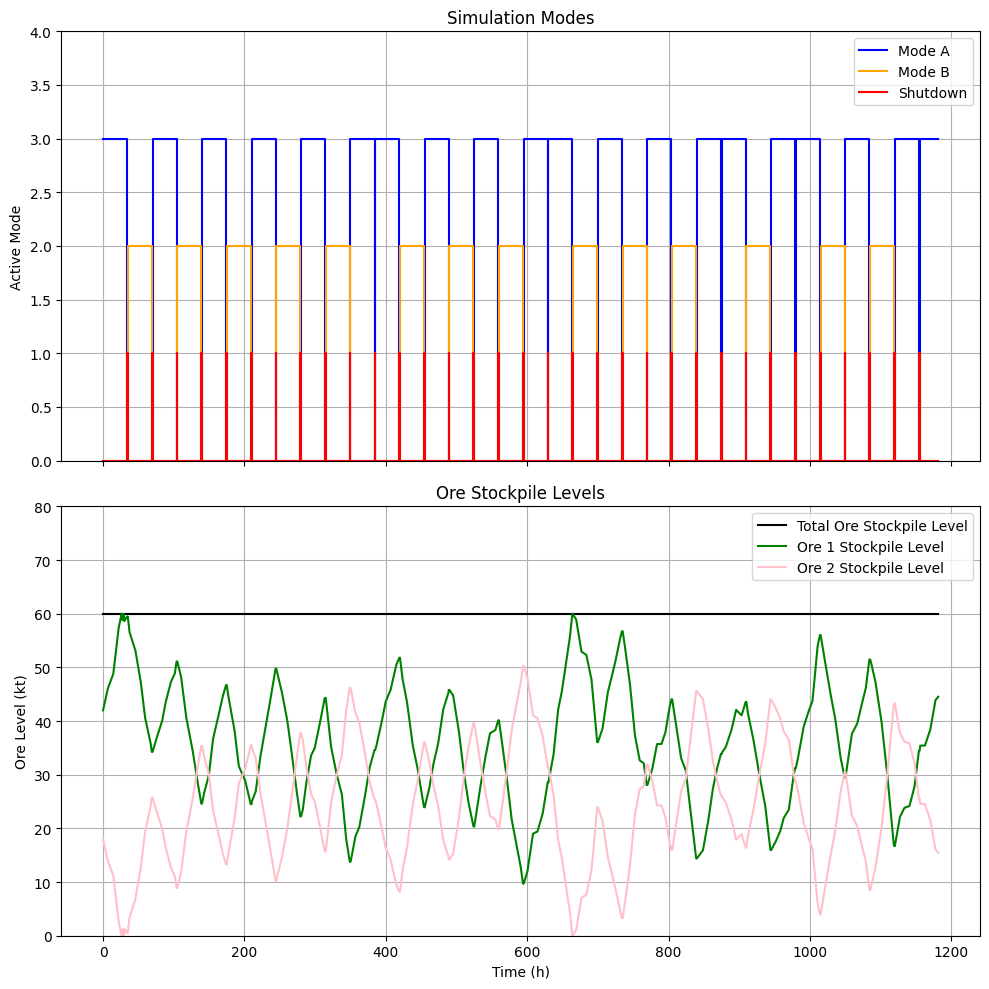

In [3]:
# Initialize Engine with decoupled parameters
print("Initializing Framework...")
model = DRSModel(parameters=mining_params)
model.load_configuration(arena_config)

# Run Simulation
print("Starting simulation loop...")
start_time = time.time()
model.run()
execution_time = time.time() - start_time

print(f"Simulation terminated successfully at TNOW: {model.TNOW:.2f} days.")
print(f"Execution Time: {execution_time:.4f} seconds.\n")

# Calculate Outputs
stats = model.calculate_statistics()
print("--- Final Simulation Statistics ---")
print(f"Total Throughput:             {stats.Throughput:,.2f} t/day")
print(f"Time in Mode A:               {stats.PortionOfTimeInModeA * 100:.2f}%")
print(f"Time in Mode B:               {stats.PortionOfTimeInModeB * 100:.2f}%")
print(f"Time in Shutdown:             {stats.PortionOfTimeInShutdown * 100:.2f}%")
print(
    f"Time in Mode A Contingency:   {stats.PortionOfTimeInModeAContingency * 100:.2f}%"
)
print(
    f"Time in Mode B Contingency:   {stats.PortionOfTimeInModeBContingency * 100:.2f}%"
)
print("-----------------------------------")

# Render Plots
model.plot_results()